# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

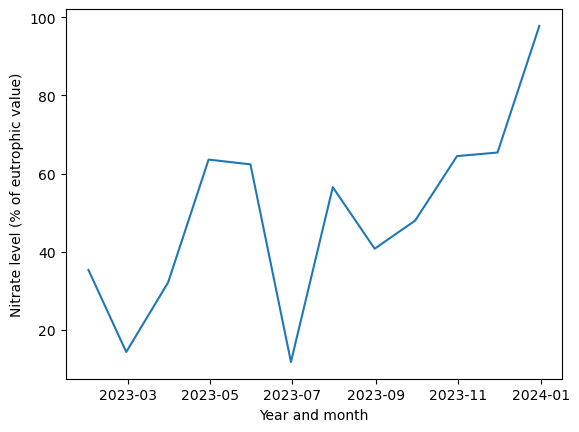

In [4]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

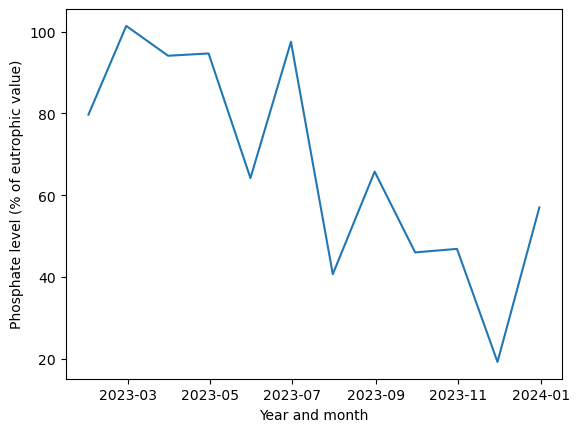

In [5]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

## Recreation of 2nd chart in figure 4.15 on page 119 of Storytelling With Data

##### Data for chart

In [6]:
countries = [
    "Australia", "Brazil", "Canada", "China", "France", "Germany", "India",
    "Italy", "Mexico", "Russia", "Spain", "Turkey", "United Kingdom", "United States"
 ]

df = pd.DataFrame(
    {
        "A": [1, 1, 2, 1, 3, 3, 4, 2, 1, 4, 2, 7, 1, 1],
        "B": [2, 3, 3, 2, 2, 1, 1, 4, 5, 3, 3, 2, 2, 2],
        "C": [3, 4, 6, 8, 4, 6, 8, 10, 4, 7, 4, 3, 3, 4],
        "D": [6, 5, 12, 4, 8, 5, 10, 9, 6, 9, 5, 4, 6, 3],
        "E": [7, 6, 8, 7, 10, 4, 5, 8, 3, 12, 11, 8, 7, 5],
    },
    index=countries,
 )

### matplotlib version

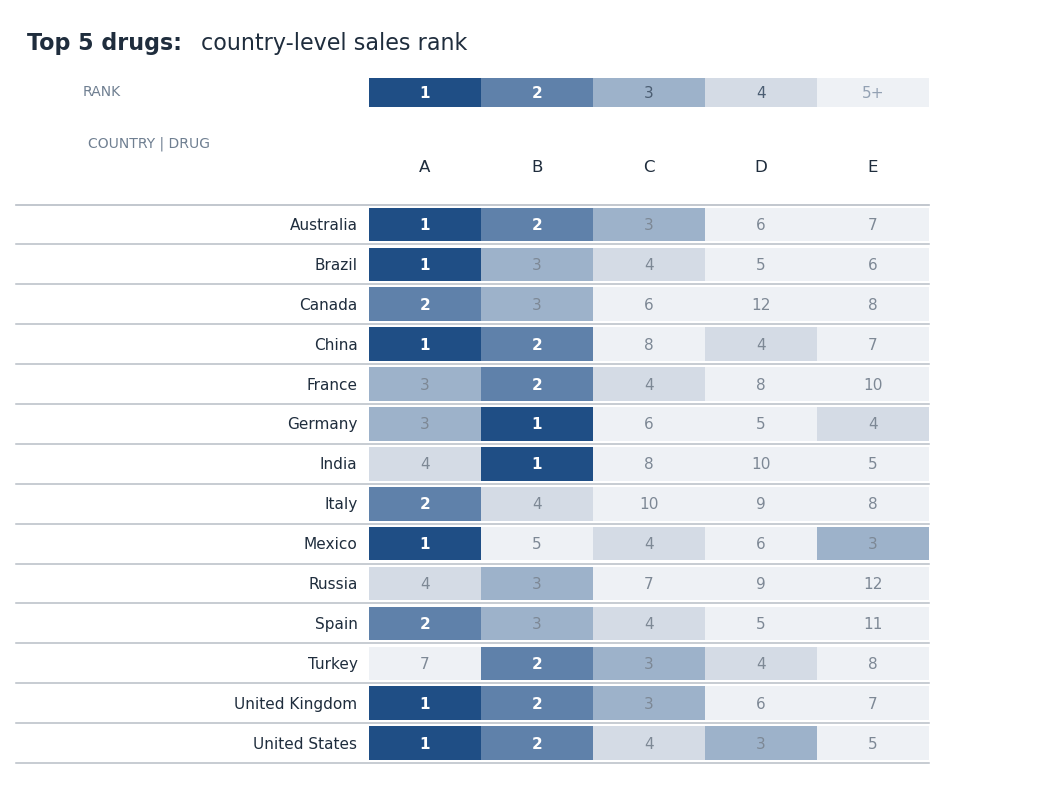

In [7]:
# graph from second heatmap in figure 4.15 on page 119 using matplotlib

# Map values to rank buckets for shading: 1,2,3,4,5+
shade_matrix = np.minimum(df.values, 5)

# Colors approximating SWD figure style
rank_colors = {
    1: "#1f4e85",
    2: "#5f81aa",
    3: "#9db2ca",
    4: "#d4dbe5",
    5: "#eef1f5",
}

fig, ax = plt.subplots(figsize=(10.5, 8.2))
ax.set_xlim(-3.2, 5.9)
ax.set_ylim(-1.4, len(countries) + 4.4)
ax.axis("off")

# Title
ax.text(
    -3.05, len(countries) + 3.55,
    "Top 5 drugs:",
    fontsize=16, fontweight="bold", ha="left", va="center", color="#1f2d3d"
 )
ax.text(
    -1.5, len(countries) + 3.55,
    "country-level sales rank",
    fontsize=16, ha="left", va="center", color="#1f2d3d"
 )

# Rank legend header
ax.text(
    -2.55, len(countries) + 2.35,
    "RANK",
    fontsize=10, color="#6f7f91", ha="left", va="center"
 )

# Rank legend boxes (1,2,3,4,5+)
legend_labels = ["1", "2", "3", "4", "5+"]
for i, label in enumerate(legend_labels):
    x0 = i
    ax.add_patch(Rectangle((x0, len(countries) + 1.95), 1, 0.72, facecolor=rank_colors[i + 1], edgecolor="none"))
    ax.text(
        x0 + 0.5, len(countries) + 2.31, label,
        ha="center", va="center",
        fontsize=11,
        color="white" if i < 2 else ("#4b5d72" if i < 4 else "#93a1b3"),
        fontweight="bold" if i < 2 else "normal"
    )

# Column headers
ax.text(
    -2.5, len(countries) + 1.05,
    "COUNTRY | DRUG",
    fontsize=10, color="#6f7f91", ha="left", va="center"
 )
for j, col in enumerate(df.columns):
    ax.text(j + 0.5, len(countries) + 0.45, col, ha="center", va="center", fontsize=12, color="#1f2d3d")

# Draw table cells and numbers
for row_idx, country in enumerate(countries):
    y = len(countries) - 1 - row_idx

    # Horizontal guide line
    ax.plot([-3.15, 5.0], [y - 0.5, y - 0.5], color="#b8bec6", lw=1.1)

    # Country label
    ax.text(-0.1, y, country, ha="right", va="center", fontsize=11, color="#1f2d3d")

    for col_idx, col in enumerate(df.columns):
        rank_value = int(df.loc[country, col])
        shade_bucket = int(shade_matrix[row_idx, col_idx])
        cell_color = rank_colors[shade_bucket]

        ax.add_patch(Rectangle((col_idx, y - 0.42), 1.0, 0.84, facecolor=cell_color, edgecolor="none"))
        ax.text(
            col_idx + 0.5, y, str(rank_value),
            ha="center", va="center",
            fontsize=11,
            color="white" if shade_bucket <= 2 else "#7d8895",
            fontweight="bold" if shade_bucket <= 2 else "normal"
        )

# Top line separating headers from data
ax.plot([-3.15, 5.0], [len(countries) - 0.5, len(countries) - 0.5], color="#b8bec6", lw=1.2)

plt.tight_layout()
plt.show()

### Seaborn version

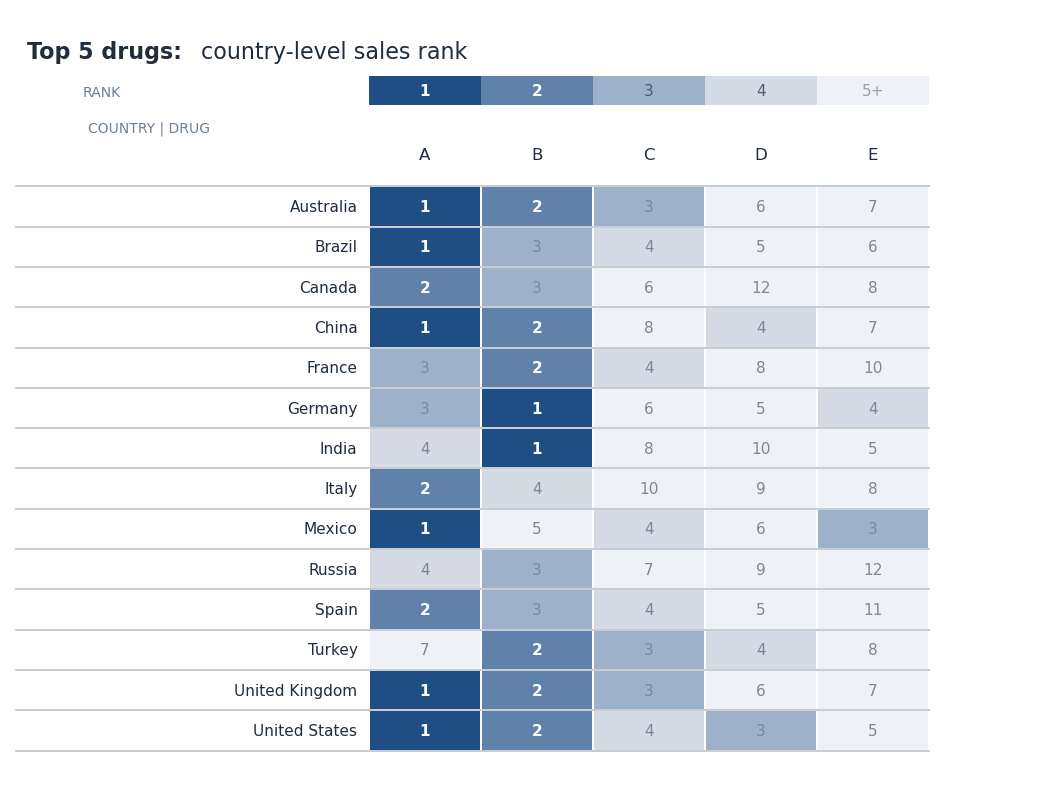

In [8]:
# Seaborn duplicate of the matplotlib chart above

shade_df = df.clip(upper=5)
rank_colors = ["#1f4e85", "#5f81aa", "#9db2ca", "#d4dbe5", "#eef1f5"]
cmap = ListedColormap(rank_colors)

fig, ax = plt.subplots(figsize=(10.5, 8.2))
sns.heatmap(
    shade_df,
    cmap=cmap,
    vmin=1, vmax=5,
    cbar=False,
    annot=df, fmt="d",
    linewidths=.25,
    xticklabels=False,
    yticklabels=False,
    ax=ax
 )

# Match the matplotlib layout area
ax.set_xlim(-3.2, 5.9)
ax.set_ylim(len(countries) + 1.2, -4.4)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(left=False, bottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Row guide lines
for i in range(len(countries) + 1):
    ax.plot([-3.15, 5.0], [i, i], color="#b8bec6", lw=1.1, zorder=5)

# Country labels
for i, country in enumerate(countries):
    ax.text(-0.1, i + 0.5, country, ha="right", va="center", fontsize=11, color="#1f2d3d")

# Column headers
ax.text(-2.5, -1.45, "COUNTRY | DRUG", fontsize=10, color="#6f7f91", ha="left", va="center")
for j, col in enumerate(df.columns):
    ax.text(j + 0.5, -0.8, col, ha="center", va="center", fontsize=12, color="#1f2d3d")

# Title
ax.text(-3.05, -3.35, "Top 5 drugs:", fontsize=16, fontweight="bold", ha="left", va="center", color="#1f2d3d")
ax.text(-1.5, -3.35, "country-level sales rank", fontsize=16, ha="left", va="center", color="#1f2d3d")

# Rank legend
ax.text(-2.55, -2.35, "RANK", fontsize=10, color="#6f7f91", ha="left", va="center")
legend_labels = ["1", "2", "3", "4", "5+"]
for i, label in enumerate(legend_labels):
    x0 = i
    ax.add_patch(Rectangle((x0, -2.75), 1, 0.72, facecolor=rank_colors[i], edgecolor="none"))
    ax.text(
        x0 + 0.5, -2.39, label,
        ha="center", va="center",
        fontsize=11,
        color="white" if i < 2 else ("#4b5d72" if i < 4 else "#93a1b3"),
        fontweight="bold" if i < 2 else "normal"
    )

# Annotation styling to match the matplotlib version
for i, text in enumerate(ax.texts[: df.shape[0] * df.shape[1]]):
    row = i // df.shape[1]
    col = i % df.shape[1]
    bucket = int(shade_df.iloc[row, col])
    if bucket <= 2:
        text.set_color("white")
        text.set_fontweight("bold")
    else:
        text.set_color("#7d8895")
        text.set_fontweight("normal")
    text.set_fontsize(11)

plt.tight_layout()
plt.show()

The following cell was created by Co-Pilot to compress the previous seaborn implementation further.

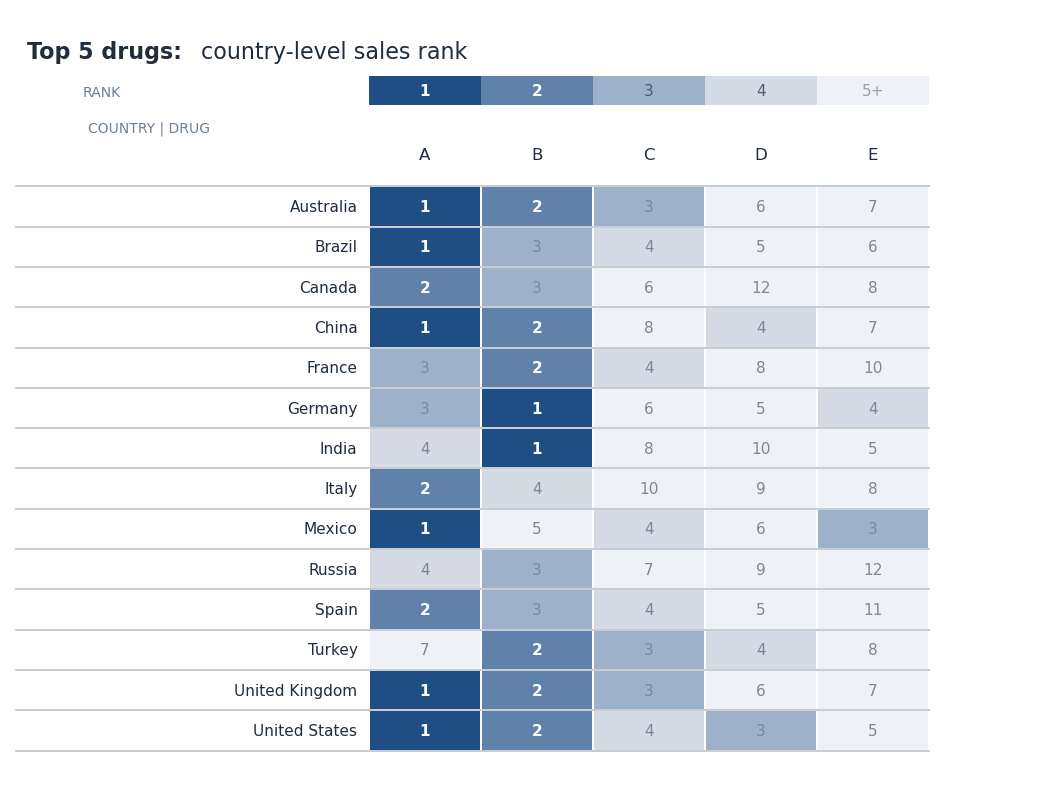

In [9]:
# Seaborn version (compact)
shade_df = df.clip(upper=5)
colors = ["#1f4e85", "#5f81aa", "#9db2ca", "#d4dbe5", "#eef1f5"]

fig, ax = plt.subplots(figsize=(10.5, 8.2))
sns.heatmap(shade_df, cmap=ListedColormap(colors), vmin=1, vmax=5, cbar=False, annot=df, fmt="d", linewidths=.25, xticklabels=False, yticklabels=False, ax=ax)

ax.set(xlim=(-3.2, 5.9), ylim=(len(countries) + 1.2, -4.4), xlabel="", ylabel="")
ax.tick_params(left=False, bottom=False)
for s in ax.spines.values(): s.set_visible(False)
for y in range(len(countries) + 1): ax.plot([-3.15, 5.0], [y, y], color="#b8bec6", lw=1.1, zorder=5)
for i, c in enumerate(countries): ax.text(-0.1, i + 0.5, c, ha="right", va="center", fontsize=11, color="#1f2d3d")
ax.text(-2.5, -1.45, "COUNTRY | DRUG", fontsize=10, color="#6f7f91", ha="left", va="center")
for j, col in enumerate(df.columns): ax.text(j + 0.5, -0.8, col, ha="center", va="center", fontsize=12, color="#1f2d3d")
ax.text(-3.05, -3.35, "Top 5 drugs:", fontsize=16, fontweight="bold", ha="left", va="center", color="#1f2d3d")
ax.text(-1.5, -3.35, "country-level sales rank", fontsize=16, ha="left", va="center", color="#1f2d3d")
ax.text(-2.55, -2.35, "RANK", fontsize=10, color="#6f7f91", ha="left", va="center")

for i, lab in enumerate(["1", "2", "3", "4", "5+"]):
    ax.add_patch(Rectangle((i, -2.75), 1, 0.72, facecolor=colors[i], edgecolor="none"))
    ax.text(i + 0.5, -2.39, lab, ha="center", va="center", fontsize=11, color="white" if i < 2 else ("#4b5d72" if i < 4 else "#93a1b3"), fontweight="bold" if i < 2 else "normal")

for k, t in enumerate(ax.texts[: df.size]):
    b = int(shade_df.iloc[k // df.shape[1], k % df.shape[1]])
    t.set(color="white" if b <= 2 else "#7d8895", fontweight="bold" if b <= 2 else "normal", fontsize=11)

plt.tight_layout()
plt.show()

It took a while to do both of these, but I wanted to compare outputs of matplotlib and seaborn. The matplotlib version was easier for generating this particular heatmap.

note that the basic heatmap using seaborn can be generated using the code below (broken up so that it is more readable). Without breaking it up, this comes to 1 line of code.  Almost all the other code was to recreate the matplotlib version and formatting.

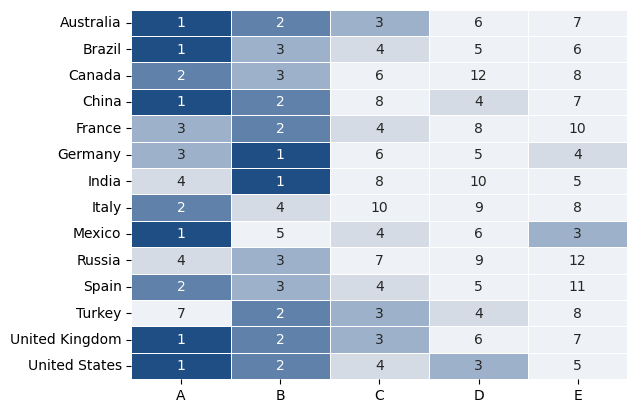

In [10]:
sns.heatmap(
    df,
    cmap=["#1f4e85", "#5f81aa", "#9db2ca", "#d4dbe5", "#eef1f5"],
    vmin=1, vmax=5,
    cbar=False,
    annot=df, fmt="d",
    linewidths=.5
 );